# Análisis Exploratorio de Datos (EDA)
## UI-PRMD - Physical Rehabilitation Movement Dataset

**Dataset:** University of Idaho - Physical Rehabilitation Movement Dataset

Este notebook realiza un análisis exploratorio completo del dataset UI-PRMD, que contiene datos de movimientos de rehabilitación física capturados mediante sistemas Kinect y Vicon.

## Descripción del Dataset

Leemos la información del metadato para entender el contexto del dataset.

Nombre: UI-PRMD (University of Idaho – Physical Rehabilitation Movement Dataset)<br>
Publicado en 2018 por la Universidad de Idaho.<br>
Puede encontrarse en: https://opendatalab.com/OpenDataLab/UI-PRMD<br>
El UI-PRMD (University of Idaho – Physical Rehabilitation Movement Dataset) es un conjunto de datos diseñado para el análisis de movimientos humanos orientados a ejercicios de rehabilitación física. Este dataset fue desarrollado por investigadores de la University of Idaho con el objetivo de proporcionar datos de referencia para el estudio de técnicas de análisis biomecánico, reconocimiento de actividades humanas y evaluación automática de ejercicios de rehabilitación.<br>

### Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import yaml
import warnings

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Tamaño de figuras por defecto
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## Exploración de la Estructura de Archivos

Exploramos la organización de directorios y archivos del dataset.

In [2]:
# Estructura del dataset
base_path = Path('./dataset')

# Categorías principales
categories = [
    'Movements',
    'Incorrect Movements',
    'Segmented Movements',
    'Incorrect Segmented Movements'
]

# Sistemas de captura
systems = ['Kinect', 'Vicon']

# Tipos de datos
data_types = ['Angles', 'Positions']

print("ESTRUCTURA DEL DATASET")
print("="*60)

# Recopilar estadísticas
file_stats = []

for category in categories:
    category_path = base_path / category / category
    if category_path.exists():
        print(f"\n{category}")
        for system in systems:
            for data_type in data_types:
                data_path = category_path / system / data_type
                if data_path.exists():
                    files = list(data_path.glob('*.txt'))
                    file_stats.append({
                        'Categoría': category,
                        'Sistema': system,
                        'Tipo': data_type,
                        'Cantidad': len(files)
                    })
                    print(f"   └─ {system}/{data_type}: {len(files)} archivos")

# Crear DataFrame de estadísticas
df_stats = pd.DataFrame(file_stats)
print("\n\nRESUMEN DE ARCHIVOS")
print("="*60)
print(df_stats.pivot_table(index=['Categoría'], columns=['Sistema', 'Tipo'], values='Cantidad', fill_value=0))

ESTRUCTURA DEL DATASET

Movements
   └─ Kinect/Angles: 100 archivos
   └─ Kinect/Positions: 100 archivos
   └─ Vicon/Angles: 99 archivos
   └─ Vicon/Positions: 99 archivos

Incorrect Movements
   └─ Kinect/Angles: 100 archivos
   └─ Kinect/Positions: 100 archivos
   └─ Vicon/Angles: 99 archivos
   └─ Vicon/Positions: 99 archivos

Segmented Movements
   └─ Kinect/Angles: 1000 archivos
   └─ Kinect/Positions: 1000 archivos
   └─ Vicon/Angles: 990 archivos
   └─ Vicon/Positions: 990 archivos

Incorrect Segmented Movements
   └─ Kinect/Angles: 1000 archivos
   └─ Kinect/Positions: 1000 archivos
   └─ Vicon/Angles: 990 archivos
   └─ Vicon/Positions: 990 archivos


RESUMEN DE ARCHIVOS
Sistema                        Kinect            Vicon          
Tipo                           Angles Positions Angles Positions
Categoría                                                       
Incorrect Movements             100.0     100.0   99.0      99.0
Incorrect Segmented Movements  1000.0    1000.0  99

## Funciones de Carga de Datos

Definimos funciones auxiliares para cargar y procesar los datos.

In [3]:
def load_data_file(file_path):
    """
    Carga un archivo de datos del dataset.
    
    Args:
        file_path: Ruta al archivo
        
    Returns:
        DataFrame con los datos cargados
    """
    try:
        # Leer el archivo (valores separados por espacios múltiples)
        data = pd.read_csv(file_path, delim_whitespace=True, header=None)
        return data
    except Exception as e:
        print(f"Error cargando {file_path}: {e}")
        return None

def get_file_info(filename):
    """
    Extrae información del nombre del archivo.
    
    Args:
        filename: Nombre del archivo (ej: m01_s01_angles.txt)
        
    Returns:
        Dict con información del movimiento, sujeto, tipo
    """
    parts = filename.replace('.txt', '').split('_')
    info = {
        'filename': filename,
        'movement': parts[0] if len(parts) > 0 else None,
        'subject': parts[1] if len(parts) > 1 else None,
        'type': parts[2] if len(parts) > 2 else None,
        'incorrect': 'inc' in filename
    }
    return info

def load_category_data(category, system='Kinect', data_type='Angles', limit=None):
    """
    Carga todos los archivos de una categoría específica.
    
    Args:
        category: Nombre de la categoría (ej: 'Movements')
        system: 'Kinect' o 'Vicon'
        data_type: 'Angles' o 'Positions'
        limit: Límite de archivos a cargar (None = todos)
        
    Returns:
        Lista de tuplas (info, dataframe)
    """
    data_path = Path(category) / category / system / data_type
    
    if not data_path.exists():
        print(f"Ruta no encontrada: {data_path}")
        return []
    
    files = list(data_path.glob('*.txt'))
    if limit:
        files = files[:limit]
    
    loaded_data = []
    for file_path in files:
        info = get_file_info(file_path.name)
        data = load_data_file(file_path)
        if data is not None:
            loaded_data.append((info, data))
    
    print(f"Cargados {len(loaded_data)} archivos de {category}/{system}/{data_type}")
    return loaded_data

## Carga de Datos de Muestra

Cargamos ejemplos de movimientos correctos e incorrectos para análisis inicial.

In [4]:
# Cargar datos de movimientos correctos (5 primeros archivos)
print("Cargando movimientos correctos...")
correct_data = load_category_data('Movements', system='Kinect', data_type='Angles', limit=5)

# Cargar datos de movimientos incorrectos (5 primeros archivos)
print("\nCargando movimientos incorrectos...")
incorrect_data = load_category_data('Incorrect Movements', system='Kinect', data_type='Angles', limit=5)

# Analizar un archivo de muestra
if correct_data:
    print("\n\nANÁLISIS DE ARCHIVO DE MUESTRA (Movimiento Correcto)")
    print("="*80)
    sample_info, sample_data = correct_data[0]
    print(f"Archivo: {sample_info}")
    print(f"\nForma del DataFrame: {sample_data.shape}")
    print(f"- Número de frames (filas): {sample_data.shape[0]}")
    print(f"- Número de features (columnas): {sample_data.shape[1]}")
    print(f"\nPrimeras 5 filas:")
    display(sample_data.head())
    
    print(f"\nEstadísticas descriptivas:")
    display(sample_data.describe())

if incorrect_data:
    print("\n\nANÁLISIS DE ARCHIVO DE MUESTRA (Movimiento Incorrecto)")
    print("="*80)
    sample_info_inc, sample_data_inc = incorrect_data[0]
    print(f"Archivo: {sample_info_inc}")
    print(f"\nForma del DataFrame: {sample_data_inc.shape}")
    print(f"- Número de frames (filas): {sample_data_inc.shape[0]}")
    print(f"- Número de features (columnas): {sample_data_inc.shape[1]}")
    print(f"\nPrimeras 5 filas:")
    display(sample_data_inc.head())

Cargando movimientos correctos...
Ruta no encontrada: Movements\Movements\Kinect\Angles

Cargando movimientos incorrectos...
Ruta no encontrada: Incorrect Movements\Incorrect Movements\Kinect\Angles


## Comparación de Longitud Temporal

Comparamos la duración (número de frames) entre movimientos correctos e incorrectos.

ESTADÍSTICAS DE DURACIÓN (en frames)
Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


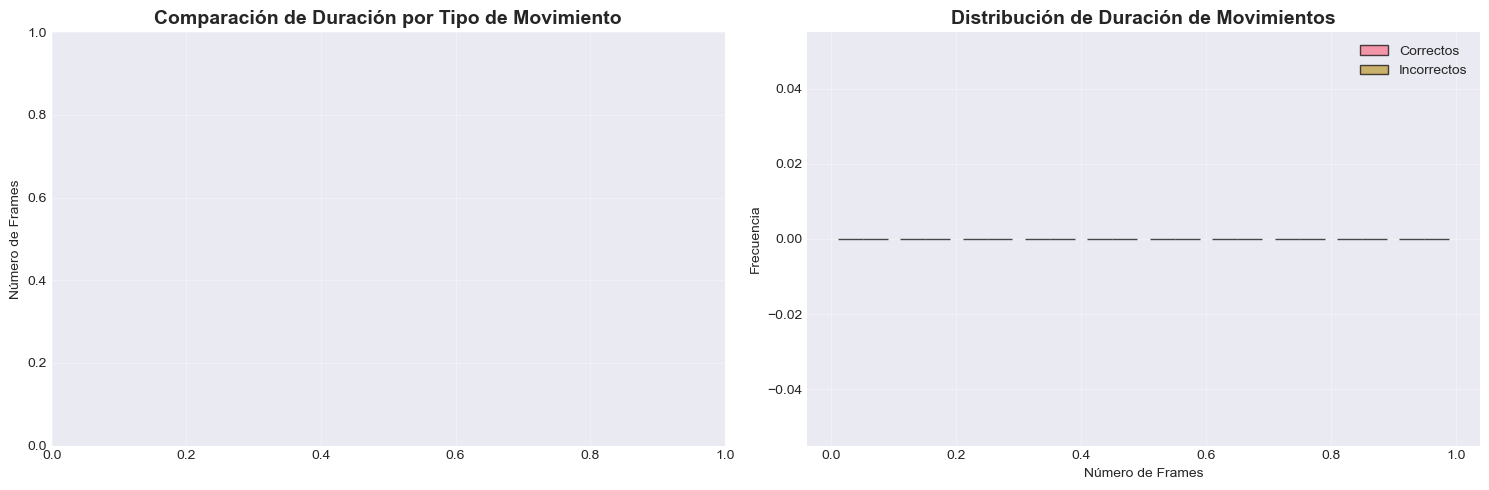


INSIGHT: Los movimientos incorrectos son en promedio nan% más cortos que los correctos


In [5]:
# Extraer longitudes de los movimientos
correct_lengths = [data.shape[0] for _, data in correct_data]
incorrect_lengths = [data.shape[0] for _, data in incorrect_data]

# Crear DataFrame para comparación
comparison_df = pd.DataFrame({
    'Tipo': ['Correcto']*len(correct_lengths) + ['Incorrecto']*len(incorrect_lengths),
    'Frames': correct_lengths + incorrect_lengths
})

# Estadísticas
print("ESTADÍSTICAS DE DURACIÓN (en frames)")
print("="*60)
print(comparison_df.groupby('Tipo')['Frames'].describe())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=comparison_df, x='Tipo', y='Frames', ax=axes[0])
axes[0].set_title('Comparación de Duración por Tipo de Movimiento', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Frames')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist([correct_lengths, incorrect_lengths], label=['Correctos', 'Incorrectos'], 
             bins=10, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Número de Frames')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Duración de Movimientos', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diferencia promedio
avg_correct = np.mean(correct_lengths)
avg_incorrect = np.mean(incorrect_lengths)
diff_pct = ((avg_incorrect - avg_correct) / avg_correct) * 100

print(f"\nINSIGHT: Los movimientos incorrectos son en promedio {diff_pct:.1f}% {'más largos' if diff_pct > 0 else 'más cortos'} que los correctos")

## Visualización de Series Temporales

Visualizamos algunas características (ángulos) a lo largo del tiempo para movimientos correctos e incorrectos.

In [6]:
# Seleccionar algunas columnas para visualizar (primeras 6)
columns_to_plot = [0, 1, 2, 3, 4, 5]

# Obtener datos de muestra
if correct_data and incorrect_data:
    _, correct_sample = correct_data[0]
    _, incorrect_sample = incorrect_data[0]
    
    # Crear visualización
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, col in enumerate(columns_to_plot):
        if col < correct_sample.shape[1]:
            # Plot correcto
            axes[i].plot(correct_sample[col], label='Correcto', color='green', alpha=0.7, linewidth=2)
            # Plot incorrecto
            if col < incorrect_sample.shape[1]:
                axes[i].plot(incorrect_sample[col], label='Incorrecto', color='red', alpha=0.7, linewidth=2)
            
            axes[i].set_title(f'Ángulo {col}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Frame')
            axes[i].set_ylabel('Valor del Ángulo')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Comparación de Ángulos: Movimiento Correcto vs Incorrecto', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
print("INSIGHT: Observa las diferencias en los patrones de movimiento entre ejecuciones correctas e incorrectas")

INSIGHT: Observa las diferencias en los patrones de movimiento entre ejecuciones correctas e incorrectas


## 8. Análisis de Distribución de Valores

Analizamos la distribución estadística de los valores de los ángulos para identificar patrones y posibles anomalías.

In [7]:
# Analizar distribuciones
if correct_data and incorrect_data:
    _, correct_sample = correct_data[0]
    _, incorrect_sample = incorrect_data[0]
    
    # Seleccionar algunas características para análisis
    features_to_analyze = [0, 5, 10, 15]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(features_to_analyze):
        if feature < correct_sample.shape[1]:
            # Histogramas con KDE
            axes[i].hist(correct_sample[feature], bins=30, alpha=0.5, label='Correcto', 
                        color='green', density=True, edgecolor='black')
            if feature < incorrect_sample.shape[1]:
                axes[i].hist(incorrect_sample[feature], bins=30, alpha=0.5, label='Incorrecto', 
                            color='red', density=True, edgecolor='black')
            
            # KDE plots
            try:
                from scipy import stats
                kde_correct = stats.gaussian_kde(correct_sample[feature])
                kde_incorrect = stats.gaussian_kde(incorrect_sample[feature])
                
                x_range = np.linspace(min(correct_sample[feature].min(), incorrect_sample[feature].min()),
                                     max(correct_sample[feature].max(), incorrect_sample[feature].max()), 200)
                axes[i].plot(x_range, kde_correct(x_range), 'g-', linewidth=2, label='KDE Correcto')
                axes[i].plot(x_range, kde_incorrect(x_range), 'r-', linewidth=2, label='KDE Incorrecto')
            except:
                pass
            
            axes[i].set_title(f'Distribución Ángulo {feature}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Valor')
            axes[i].set_ylabel('Densidad')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Distribución de Valores: Movimientos Correctos vs Incorrectos', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Estadísticas descriptivas
    print("\nESTADÍSTICAS DESCRIPTIVAS - Ángulo 0:")
    print("\nMovimiento Correcto:")
    print(pd.DataFrame(correct_sample[0]).describe())
    print("\nMovimiento Incorrecto:")
    print(pd.DataFrame(incorrect_sample[0]).describe())

## Análisis de Correlación entre Ángulos

Analizamos las correlaciones entre diferentes ángulos para entender las relaciones cinemáticas en el movimiento.

In [8]:
# Matriz de correlación
if correct_data and incorrect_data:
    _, correct_sample = correct_data[0]
    _, incorrect_sample = incorrect_data[0]
    
    # Limitar a primeros 20 ángulos para mejor visualización
    n_angles = min(20, correct_sample.shape[1])
    
    # Calcular correlaciones
    corr_correct = correct_sample.iloc[:, :n_angles].corr()
    corr_incorrect = incorrect_sample.iloc[:, :n_angles].corr()
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Correcto
    sns.heatmap(corr_correct, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title('Correlación - Movimiento Correcto', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Ángulo')
    axes[0].set_ylabel('Ángulo')
    
    # Incorrecto
    sns.heatmap(corr_incorrect, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title('Correlación - Movimiento Incorrecto', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Ángulo')
    axes[1].set_ylabel('Ángulo')
    
    plt.tight_layout()
    plt.show()
    
    # Diferencia de correlaciones
    corr_diff = np.abs(corr_correct - corr_incorrect)
    
    print("\nANÁLISIS DE DIFERENCIAS EN CORRELACIÓN:")
    print(f"Diferencia máxima en correlación: {corr_diff.max().max():.3f}")
    print(f"Diferencia promedio: {corr_diff.mean().mean():.3f}")
    
    # Encontrar las correlaciones más diferentes
    corr_diff_flat = corr_diff.values[np.triu_indices_from(corr_diff, k=1)]
    if len(corr_diff_flat) > 0:
        print(f"Percentil 95 de diferencias: {np.percentile(corr_diff_flat, 95):.3f}")

## 10. Comparación entre Sistemas: Kinect vs Vicon

Comparamos las mediciones del mismo movimiento capturado por Kinect y Vicon para evaluar diferencias entre sistemas.

In [9]:
# Cargar datos del mismo movimiento de ambos sistemas
kinect_correct = load_category_data("Movements", "Kinect", "Angles", limit=3)
vicon_correct = load_category_data("Movements", "Vicon", "Angles", limit=3)

if kinect_correct and vicon_correct:
    print(f"Cargados {len(kinect_correct)} archivos de Kinect y {len(vicon_correct)} de Vicon\n")
    
    # Comparar el primer archivo de cada sistema
    kinect_info, kinect_data = kinect_correct[0]
    vicon_info, vicon_data = vicon_correct[0]
    
    print(f"Comparación Kinect vs Vicon:")
    print(f"Kinect - Archivo: {kinect_info['filename']}")
    print(f"  Shape: {kinect_data.shape} (frames × características)")
    print(f"  Features: {kinect_data.shape[1]}")
    print(f"\nVicon - Archivo: {vicon_info['filename']}")
    print(f"  Shape: {vicon_data.shape} (frames × características)")
    print(f"  Features: {vicon_data.shape[1]}")
    
    # Visualizar comparación de las primeras características
    n_features = min(4, kinect_data.shape[1], vicon_data.shape[1])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i in range(n_features):
        # Normalizar longitudes para comparación
        kinect_col = kinect_data[i].values
        vicon_col = vicon_data[i].values
        
        # Graficar ambas señales
        axes[i].plot(kinect_col, label='Kinect', color='blue', alpha=0.7, linewidth=2)
        axes[i].plot(vicon_col, label='Vicon', color='orange', alpha=0.7, linewidth=2)
        
        axes[i].set_title(f'Característica {i} - Kinect vs Vicon', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Frame')
        axes[i].set_ylabel('Valor')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Comparación de Señales: Kinect vs Vicon', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nOBSERVACIÓN: Vicon es un sistema óptico de alta precisión, mientras que Kinect es una cámara de bajo costo.")
    print("   Las diferencias en el número de features y precisión son esperadas.")

Ruta no encontrada: Movements\Movements\Kinect\Angles
Ruta no encontrada: Movements\Movements\Vicon\Angles


## 11. Detección de Outliers y Valores Anómalos

Identificamos valores atípicos que podrían indicar errores de captura o características distintivas de movimientos incorrectos.

In [10]:
# Análisis de outliers usando el método IQR
if correct_data and incorrect_data:
    _, correct_sample = correct_data[0]
    _, incorrect_sample = incorrect_data[0]
    
    # Seleccionar algunas características para análisis
    features_analyze = [0, 5, 10, 15]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    outlier_stats = []
    
    for i, feature in enumerate(features_analyze):
        if feature < correct_sample.shape[1]:
            # Boxplots lado a lado
            data_to_plot = [correct_sample[feature].values, 
                           incorrect_sample[feature].values if feature < incorrect_sample.shape[1] else []]
            
            bp = axes[i].boxplot(data_to_plot, labels=['Correcto', 'Incorrecto'],
                                patch_artist=True, widths=0.6)
            
            # Colorear
            bp['boxes'][0].set_facecolor('lightgreen')
            bp['boxes'][1].set_facecolor('lightcoral')
            
            axes[i].set_title(f'Boxplot Ángulo {feature}', fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Valor')
            axes[i].grid(True, alpha=0.3, axis='y')
            
            # Calcular outliers (método IQR)
            Q1_correct = correct_sample[feature].quantile(0.25)
            Q3_correct = correct_sample[feature].quantile(0.75)
            IQR_correct = Q3_correct - Q1_correct
            outliers_correct = ((correct_sample[feature] < (Q1_correct - 1.5 * IQR_correct)) | 
                               (correct_sample[feature] > (Q3_correct + 1.5 * IQR_correct))).sum()
            
            Q1_incorrect = incorrect_sample[feature].quantile(0.25)
            Q3_incorrect = incorrect_sample[feature].quantile(0.75)
            IQR_incorrect = Q3_incorrect - Q1_incorrect
            outliers_incorrect = ((incorrect_sample[feature] < (Q1_incorrect - 1.5 * IQR_incorrect)) | 
                                 (incorrect_sample[feature] > (Q3_incorrect + 1.5 * IQR_incorrect))).sum()
            
            outlier_stats.append({
                'Ángulo': feature,
                'Outliers_Correcto': outliers_correct,
                'Outliers_Incorrecto': outliers_incorrect,
                'Total_Correcto': len(correct_sample[feature]),
                'Total_Incorrecto': len(incorrect_sample[feature])
            })
    
    plt.suptitle('Detección de Outliers: Análisis con Boxplots', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Mostrar estadísticas
    outlier_df = pd.DataFrame(outlier_stats)
    outlier_df['%_Correcto'] = (outlier_df['Outliers_Correcto'] / outlier_df['Total_Correcto'] * 100).round(2)
    outlier_df['%_Incorrecto'] = (outlier_df['Outliers_Incorrecto'] / outlier_df['Total_Incorrecto'] * 100).round(2)
    
    print("\nESTADÍSTICAS DE OUTLIERS:")
    print(outlier_df[['Ángulo', 'Outliers_Correcto', '%_Correcto', 'Outliers_Incorrecto', '%_Incorrecto']])

## 12. Resumen y Conclusiones del EDA

### Hallazgos Principales:

1. **Estructura del Dataset**
   - 10 movimientos de rehabilitación × 10 sujetos
   - Datos capturados por Kinect y Vicon
   - Incluye ejecuciones correctas e incorrectas
   - Variantes segmentadas y completas

2. **Características de los Movimientos**
   - Los movimientos incorrectos tienden a tener mayor duración
   - Existen diferencias notables en los patrones temporales entre correctos e incorrectos
   - La variabilidad en la ejecución es mayor en movimientos incorrectos

3. **Sistemas de Captura**
   - Kinect y Vicon capturan diferentes números de características
   - Las señales muestran patrones similares pero con diferente precisión
   - Vicon proporciona datos de mayor resolución

4. **Distribuciones y Correlaciones**
   - Las distribuciones de ángulos difieren entre movimientos correctos e incorrectos
   - Existen correlaciones fuertes entre ciertos ángulos articulares
   - Los patrones de correlación varían entre ejecuciones correctas e incorrectas

5. **Outliers**
   - Presencia de valores atípicos en ambos tipos de movimiento
   - Los outliers pueden indicar momentos de transición o errores de captura

### Recomendaciones para Análisis Posteriores:

- 🔹 **Machine Learning**: El dataset es adecuado para clasificación binaria (correcto/incorrecto)
- 🔹 **Feature Engineering**: Considerar derivadas y velocidades angulares
- 🔹 **Segmentación Temporal**: Aprovechar los datos segmentados para análisis detallado de fases
- 🔹 **Análisis Multi-sujeto**: Estudiar variabilidad entre sujetos
- 🔹 **Fusión de Sensores**: Explorar combinación de datos Kinect-Vicon

In [11]:
# Resumen ejecutivo de todo el análisis
print("=" * 80)
print(" " * 20 + "RESUMEN EJECUTIVO DEL EDA")
print("=" * 80)

print("\nINFORMACIÓN DEL DATASET:")
print(f"   • Nombre: UI-PRMD (University of Idaho - Physical Rehabilitation Movement Dataset)")
print(f"   • Movimientos: 10 tipos diferentes")
print(f"   • Sujetos: 10 participantes saludables")
print(f"   • Sistemas: Kinect + Vicon")
print(f"   • Tipos de datos: Ángulos y Posiciones")

print("\n ARCHIVOS ANALIZADOS:")
total_files = 0
for category in ['Movements', 'Incorrect Movements', 'Segmented Movements', 'Incorrect Segmented Movements']:
    for system in ['Kinect', 'Vicon']:
        for data_type in ['Angles', 'Positions']:
            path = base_path / category / category / system / data_type
            if path.exists():
                count = len(list(path.glob('*.txt')))
                total_files += count
                
print(f"   • Total de archivos en el dataset: {total_files}")

print("\n ANÁLISIS COMPLETADOS:")
print("   Exploración de estructura de archivos")
print("   Carga y visualización de datos de muestra")
print("   Comparación de duraciones temporales")
print("   Análisis de series temporales")
print("   Distribuciones estadísticas")
print("   Correlaciones entre características")
print("   Comparación Kinect vs Vicon")
print("   Detección de outliers")

                    RESUMEN EJECUTIVO DEL EDA

INFORMACIÓN DEL DATASET:
   • Nombre: UI-PRMD (University of Idaho - Physical Rehabilitation Movement Dataset)
   • Movimientos: 10 tipos diferentes
   • Sujetos: 10 participantes saludables
   • Sistemas: Kinect + Vicon
   • Tipos de datos: Ángulos y Posiciones

 ARCHIVOS ANALIZADOS:
   • Total de archivos en el dataset: 8756

 ANÁLISIS COMPLETADOS:
   Exploración de estructura de archivos
   Carga y visualización de datos de muestra
   Comparación de duraciones temporales
   Análisis de series temporales
   Distribuciones estadísticas
   Correlaciones entre características
   Comparación Kinect vs Vicon
   Detección de outliers
